<a href="https://colab.research.google.com/github/sharvaripd/DL-/blob/main/CNN_LeNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#LeNET-5 CNN FOR MNIST CLASSIFICATION
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, AveragePooling2D


In [ ]:
#LOAD THE MNIST DATASET
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("Training data",x_train.shape)
print("Testing data",x_test.shape)

Training data (60000, 28, 28)
Testing data (10000, 28, 28)


In [ ]:
#Normalize the images
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
#Adding the channel dimension
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)
#After Reshaping
print("Training data",x_train.shape)
print("Testing data",x_test.shape)

Training data (60000, 28, 28, 1)
Testing data (10000, 28, 28, 1)


In [ ]:
#Creating LE NET -5 CNN
model = Sequential([
    #C1 convolutional layer
    layers.Conv2D(filters=6,kernel_size=(5,5),activation='tanh', input_shape=(28,28,1)),
    #P1 Pooling layer
    layers.AveragePooling2D(pool_size=(2,2), strides=2),
    #C2
    layers.Conv2D(filters=16,kernel_size=(5,5),activation='tanh'),
    #P2 Pooling layer
    layers.AveragePooling2D(pool_size=(2,2), strides=2),
    #Flatten
    layers.Flatten(),
    #Fully connected layer
    layers.Dense(units=120,activation='tanh'),
    layers.Dense(units=84,activation='tanh'),
    #output layer
    layers.Dense(units=10,activation='softmax')
])



In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compile the model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
#Train the model
history = model.fit(x_train,y_train,epochs=10, batch_size = 128, validation_split=0.1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.8893 - loss: 0.3801 - val_accuracy: 0.9570 - val_loss: 0.1538
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.9568 - loss: 0.1415 - val_accuracy: 0.9735 - val_loss: 0.0944
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9722 - loss: 0.0912 - val_accuracy: 0.9803 - val_loss: 0.0685
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 54ms/step - accuracy: 0.9782 - loss: 0.0690 - val_accuracy: 0.9827 - val_loss: 0.0614
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.9839 - loss: 0.0541 - val_accuracy: 0.9828 - val_loss: 0.0573
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.9872 - loss: 0.0420 - val_accuracy: 0.9847 - val_loss: 0.0512
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9888 - loss: 0.0359 - val_accuracy: 0.9832 - val_loss: 0.0551
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.9906 - loss: 0.0305 - 

In [ ]:
#test themodel
test_loss, test_acc = model.evaluate(x_test,y_test)
print("Test accuracy",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9867 - loss: 0.0420
Test accuracy 0.9866999983787537


In [ ]:
#Prediction
predictions = model.predict(x_test)
print("Predicted digit:",predictions[0].argmax())
print("Actual digit:",y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Predicted digit: 7
Actual digit: 7


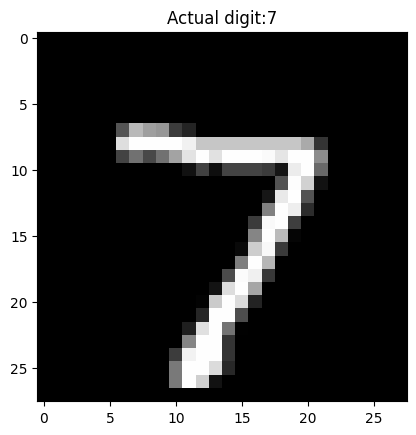

In [ ]:
plt.imshow(x_test[0].reshape(28,28),cmap='gray')
plt.title("Predicted digit:"+str(predictions[0].argmax()))
plt.title("Actual digit:"+str(y_test[0]))
plt.show()